In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sys
import os

# Import the Kerr-Schild data loader from the analysis folder
import datalib_gr_ks as ks

# Also import base datalib for reference
from datalib import Data, flag_to_species


ModuleNotFoundError: No module named 'datalib'

# Access Aperture4 Simulation Data

This notebook demonstrates how to access variables from Aperture4 simulation output in `/data/personal/Alex_Chen/Torus/Data_vert_B0.6_pair/`.

We use the analysis tools from `analysis_folder` and `Aperture4/external/Aperture_plotting`.

In [ ]:
# Add Aperture4 python modules to path
sys.path.insert(0, '/home/aaron/Research/Aperture4/python')
sys.path.insert(0, '/home/aaron/Research/Aperture4/external/Aperture_plotting')

# Add current analysis folder to path
sys.path.insert(0, '/home/aaron/Research/Aperture4/problems/gr_2d_kerr_schild/analysis_folder')

print("Python paths configured:")
for p in sys.path[:3]:
    print(f"  {p}")

Python paths configured:
  /home/aaron/Research/Aperture4/problems/gr_2d_kerr_schild/analysis_folder
  /home/aaron/Research/Aperture4/external/Aperture_plotting
  /home/aaron/Research/Aperture4/python


## Define Data Directory and Inspect Contents

The simulation data is stored in `/data/personal/Alex_Chen/Torus/Data_vert_B0.6_pair/`.

In [11]:
# Define the data directory
data_dir = "/data/personal/Alex_Chen/Torus/Data_vert_B0.6_pair/"

# Check what files are available
import glob
fld_files = sorted(glob.glob(os.path.join(data_dir, "fld.*.h5")))[:5]
ptc_files = sorted(glob.glob(os.path.join(data_dir, "ptc.*.h5")))[:5]

print(f"Data directory: {data_dir}")
print(f"\nFirst 5 field files:")
for f in fld_files:
    print(f"  {os.path.basename(f)}")
print(f"\nFirst 5 particle files:")
for f in ptc_files:
    print(f"  {os.path.basename(f)}")

# Check for grid and config files
print(f"\nGrid file exists: {os.path.exists(os.path.join(data_dir, 'grid.h5'))}")
print(f"Config file exists: {os.path.exists(os.path.join(data_dir, 'config.toml'))}")

Data directory: /data/personal/Alex_Chen/Torus/Data_vert_B0.6_pair/

First 5 field files:
  fld.00000.h5
  fld.00001.h5
  fld.00002.h5
  fld.00003.h5
  fld.00004.h5

First 5 particle files:
  ptc.00000.h5
  ptc.00001.h5
  ptc.00002.h5
  ptc.00003.h5
  ptc.00004.h5

Grid file exists: True
Config file exists: True


## Load Simulation Data with `DataKerrSchild`

We use the `DataKerrSchild` class from `datalib_gr_ks.py` to load the simulation data. This class:
- Reads the configuration from `config.toml`
- Loads the grid from `grid.h5`
- Sets up Kerr-Schild metric quantities
- Provides lazy loading of field and particle variables

In [12]:
# Load the simulation data
print("Loading data... this may take a moment")
data = ks.DataKerrSchild(data_dir)

print(f"\nData loaded successfully!")
print(f"Black hole spin (a): {data.a}")
print(f"Outer horizon radius (rH): {data.rH}")
print(f"Number of field steps: {len(data.fld_steps)}")
print(f"Field steps range: {data.fld_steps[0]} to {data.fld_steps[-1]}")
print(f"Number of particle steps: {len(data.ptc_steps)}")
print(f"Particle steps range: {data.ptc_steps[0]} to {data.ptc_steps[-1]}")

# Show configuration parameters
print(f"\nConfiguration keys:")
for key in data.conf.keys():
    print(f"  {key}: {data.conf[key]}")

Loading data... this may take a moment


/home/aaron/Research/Aperture4/problems/gr_2d_kerr_schild/analysis_folder/datalib_gr_ks.py:79: RuntimeWarning: divide by zero encountered in divide
  return 1.0/Sigma(r,th,a)/np.sin(th)**2



Data loaded successfully!
Black hole spin (a): 0.998
Outer horizon radius (rH): 1.0632139225171164
Number of field steps: 2649
Field steps range: 0 to 2648
Number of particle steps: 2649
Particle steps range: 0 to 2648

Configuration keys:
  log_level: 0
  dt: 0.00025
  max_steps: 12000000
  fld_output_interval: 4000
  ptc_output_interval: 4000
  snapshot_interval: 40000
  rho_interval: 1
  max_ptc_num: 300000000
  max_ph_num: 100000000
  ptc_buffer_size: 10000000
  ph_buffer_size: 10000000
  ptc_segment_size: 20000000
  ph_segment_size: 20000000
  max_tracked_num: 4000000
  current_smoothing: 5
  tracked_fraction: 0.01
  q_e: 1.0
  bh_spin: 0.998
  use_implicit: True
  implicit_beta: 0.53
  ranks: [1, 4]
  N: [4096, 4096]
  size: [4.45, 3.141592654]
  lower: [0.0, 0.0]
  guard: [2, 2]
  periodic_boundary: [False, False]
  damping_length: 64
  damping_coef: 0.005
  damping_length_horizon: 16
  damping_coef_horizon: 0.01
  damp_to_background: True
  downsample: 2
  output_dir: Data_ver

## Access and Inspect Available Variables

The `DataKerrSchild` class provides access to field data, particle data, mesh data, and computed quantities.

In [13]:
# List all available variable keys
print("Available field keys:")
print(data._fld_keys)

print("\nAvailable particle keys:")
print(data._ptc_keys)

print("\nAvailable mesh keys:")
print(data._mesh_keys)

# Access a field variable (lazy loading - only loads when accessed)
print("\n--- Accessing field variables ---")
print(f"Rho_e shape: {data.Rho_e.shape}")
print(f"Rho_p shape: {data.Rho_p.shape}")
print(f"E1 shape: {data.E1.shape}")
print(f"B1 shape: {data.B1.shape}")

# Access computed quantities
print("\n--- Accessing computed quantities ---")
print(f"plasma_beta shape: {data.plasma_beta.shape}")
print(f"n_proper shape: {data.n_proper.shape}")

# Access mesh coordinates
print("\n--- Mesh coordinates ---")
print(f"x1 (R = r*sin(theta)) shape: {data.x1.shape}")
print(f"x2 (z = r*cos(theta)) shape: {data.x2.shape}")
print(f"_rv (r) shape: {data._rv.shape}")
print(f"_thetav (theta) shape: {data._thetav.shape}")

Available field keys:
['B1', 'B2', 'B3', 'B_sqr', 'Bmag', 'DdotB', 'E1', 'E2', 'E3', 'E_sqr', 'J01', 'J02', 'J03', 'J1', 'J2', 'J3', 'Jmag', 'Rho_e', 'Rho_p', 'Rho_ph', 'Rho_total', 'auxE1', 'auxE2', 'auxE3', 'auxH1', 'auxH2', 'auxH3', 'divB', 'divE', 'flux', 'flux_e1', 'flux_e2', 'flux_e3', 'flux_p1', 'flux_p2', 'flux_p3', 'flux_ph1', 'flux_ph2', 'flux_ph3', 'num_e', 'num_p', 'num_ph', 'pair_produced', 'photon_produced', 'step', 'stress_e00', 'stress_e01', 'stress_e02', 'stress_e03', 'stress_e11', 'stress_e12', 'stress_e13', 'stress_e22', 'stress_e23', 'stress_e33', 'stress_p00', 'stress_p01', 'stress_p02', 'stress_p03', 'stress_p11', 'stress_p12', 'stress_p13', 'stress_p22', 'stress_p23', 'stress_p33', 'stress_ph00', 'stress_ph01', 'stress_ph02', 'stress_ph03', 'stress_ph11', 'stress_ph12', 'stress_ph13', 'stress_ph22', 'stress_ph23', 'stress_ph33', 'time', 'fluxB', 'Dd1', 'Dd2', 'Dd3', 'D', 'Bd1', 'Bd2', 'Bd3', 'B', 'Ed1', 'Ed2', 'Ed3', 'Hd1', 'Hd2', 'Hd3', 'sigma', 'flux_upper', 'f

/home/aaron/Research/Aperture4/problems/gr_2d_kerr_schild/analysis_folder/datalib_gr_ks.py:318: RuntimeWarning: invalid value encountered in divide
  b1 = -u_lower[...,0] * B[...,1] / alpha_val - (u_lower[...,2] * E[...,3] - u_lower[...,3] * E[...,2]) / alpha_val / sqrt_gm
/home/aaron/Research/Aperture4/problems/gr_2d_kerr_schild/analysis_folder/datalib_gr_ks.py:319: RuntimeWarning: invalid value encountered in divide
  b2 = -u_lower[...,0] * B[...,2] / alpha_val - (u_lower[...,3] * E[...,1] - u_lower[...,1] * E[...,3]) / alpha_val / sqrt_gm
/home/aaron/Research/Aperture4/problems/gr_2d_kerr_schild/analysis_folder/datalib_gr_ks.py:320: RuntimeWarning: invalid value encountered in divide
  b3 = -u_lower[...,0] * B[...,3] / alpha_val - (u_lower[...,1] * E[...,2] - u_lower[...,2] * E[...,1]) / alpha_val / sqrt_gm
/home/aaron/Research/Aperture4/problems/gr_2d_kerr_schild/analysis_folder/datalib_gr_ks.py:345: RuntimeWarning: invalid value encountered in divide
  b_upper = self.frf_B / bnorm

plasma_beta shape: (2048, 2048)
n_proper shape: (2048, 2048)

--- Mesh coordinates ---
x1 (R = r*sin(theta)) shape: (2048, 2048)
x2 (z = r*cos(theta)) shape: (2048, 2048)
_rv (r) shape: (2048, 2048)
_thetav (theta) shape: (2048, 2048)


## Extract Fields into NumPy Arrays

You can extract any field variable into a NumPy array for further analysis or custom visualization.

In [14]:
# Extract specific fields into numpy arrays
rho_e = data.Rho_e
rho_p = data.Rho_p
E1 = data.E1
B1 = data.B1
B2 = data.B2
B3 = data.B3

# Computed quantities
beta = data.plasma_beta
n_proper = data.n_proper

# Get coordinates
R = data.x1  # cylindrical radius = r * sin(theta)
z = data.x2  # height = r * cos(theta)

print("Extracted arrays:")
print(f"  rho_e: shape={rho_e.shape}, min={np.min(rho_e):.3e}, max={np.max(rho_e):.3e}")
print(f"  rho_p: shape={rho_p.shape}, min={np.min(rho_p):.3e}, max={np.max(rho_p):.3e}")
print(f"  E1: shape={E1.shape}, min={np.min(E1):.3e}, max={np.max(E1):.3e}")
print(f"  B1: shape={B1.shape}, min={np.min(B1):.3e}, max={np.max(B1):.3e}")
print(f"  plasma_beta: shape={beta.shape}, min={np.min(beta):.3e}, max={np.max(beta):.3e}")
print(f"  n_proper: shape={n_proper.shape}, min={np.min(n_proper):.3e}, max={np.max(n_proper):.3e}")

# You can also compute your own quantities
B_magnitude = np.sqrt(B1**2 + B2**2 + B3**2)
print(f"\nCustom computed B_magnitude: shape={B_magnitude.shape}, min={np.min(B_magnitude):.3e}, max={np.max(B_magnitude):.3e}")

Extracted arrays:
  rho_e: shape=(2048, 2048), min=-1.175e+03, max=0.000e+00
  rho_p: shape=(2048, 2048), min=0.000e+00, max=1.174e+03
  E1: shape=(2048, 2048), min=-1.102e-01, max=9.723e-02
  B1: shape=(2048, 2048), min=-5.931e-01, max=5.931e-01
  plasma_beta: shape=(2048, 2048), min=nan, max=nan
  n_proper: shape=(2048, 2048), min=0.000e+00, max=2.191e+03

Custom computed B_magnitude: shape=(2048, 2048), min=6.949e-03, max=6.898e-01


## Load Different Time Steps

You can load different time steps using `load_fld()` for field data and `load_ptc()` for particle data.

In [15]:
# Example: Load a different field step
step_to_load = data.fld_steps[10]  # Load the 11th step
print(f"Loading field step: {step_to_load}")
data.load_fld(step_to_load)

# Now data.Rho_e etc. will return values from the newly loaded step
rho_e_new = data.Rho_e
print(f"New rho_e shape: {rho_e_new.shape}")
print(f"New rho_e min: {np.min(rho_e_new):.3e}, max: {np.max(rho_e_new):.3e}")

# Load back the first step
data.load_fld(data.fld_steps[0])
print(f"\nReloaded initial step: {data.fld_steps[0]}")

# Time series example: get a time series of a field quantity
print("\n--- Time series example ---")
print("To get a time series, you can use data.time_series_fld('Rho_e')")
print("This returns a list of arrays for each field step.")
print(f"Total field steps available: {len(data.fld_steps)}")
print(f"Steps: {data.fld_steps[:5]} ... {data.fld_steps[-5:]}")

Loading field step: 10
New rho_e shape: (2048, 2048)
New rho_e min: -1.362e+03, max: 0.000e+00

Reloaded initial step: 0

--- Time series example ---
To get a time series, you can use data.time_series_fld('Rho_e')
This returns a list of arrays for each field step.
Total field steps available: 2649
Steps: [0, 1, 2, 3, 4] ... [2644, 2645, 2646, 2647, 2648]


# Calculating Thermal Synchrotron Emission

## Mathematical Background

Starting from the thermal electron distribution

$$
N(\gamma)=\frac{n\gamma^2\beta e^{-\gamma/\theta_e}}{\theta_e K_2(\theta_e^{-1})},
$$

and the emissivity

$$
j^{\alpha\beta}=\int_0^\infty N(\gamma)\,\epsilon^{\alpha\beta}\,d\gamma,
$$

where

- The single-particle emissivity is
  $$
  \epsilon^{\alpha\beta}=\frac{\sqrt{3}e^2}{8\pi c}\nu_B\sin\theta_B\,H^{\alpha\beta}(\nu,\theta_B),
  $$
  with
  $$
  H^{11}=F\!\left(\frac{\nu}{\nu_c}\right)-G\!\left(\frac{\nu}{\nu_c}\right),\qquad
  H^{22}=F\!\left(\frac{\nu}{\nu_c}\right)+G\!\left(\frac{\nu}{\nu_c}\right),\qquad
  H^{12}=-H^{21}=\frac{4i\cot\theta_B}{3\gamma}H\!\left(\frac{\nu}{\nu_c}\right).
  $$

- $\gamma$ and $\beta$ are the electron Lorentz factor and corresponding velocity factor, while the dimensionless electron temperature is
  $$
  \theta_e=\frac{kT}{mc^2}.
  $$

- The emitted frequency is $\nu$, with
  $$
  \nu_c=\frac{3}{2}\nu_B\sin\theta_B\,\gamma^2,\qquad
  \nu_B=\frac{eB}{2\pi mc}.
  $$

- The synchrotron functions are
  $$
  F(x)=x\int_x^\infty K_{5/3}(y)\,dy,\qquad
  G(x)=xK_{2/3}(x),\qquad
  H(x)=\int_x^\infty K_{1/3}(y)\,dy+xK_{1/3}(x).
  $$

Since we only care about intensity (and not polarization), we need only

$$
j_I=j^{22}+j^{11}.
$$

Following a very similar process, but without the earlier two assumptions, we can follow my notes (which are still probably off by a factor of $2\pi$ compared to Dexter) to obtain

$$
j_I=\frac{1}{2\pi}\frac{ne^2}{\sqrt{3}\,K_2(\theta_e^{-1})\,\theta_e}\,\nu\,I_I(x),
$$

where

$$
I_I(x)=\frac{1}{x}\int_0^\infty F\!\left(\frac{x}{z^2}\right)z\sqrt{z^2\theta_e^2-1}\,e^{-z}\,dz,
\qquad
x=\frac{\nu}{\nu_c'},
\qquad
\nu_c'=\frac{\nu_c}{z^2} = \frac{3}{2}\nu_B \sin(\theta_B)\theta_e^2.
$$

Note that I drop the $2\pi$ in further calculations to match Dexter

## Theoretical Calculation

In [275]:
from scipy.integrate import quad, quad_vec
from scipy.special import kv
from scipy.interpolate import CubicSpline
from scipy.optimize import minimize_scalar

In [276]:
#Constants
c = 3e10 #cm/s
m_e = 9.11e-28 #g
q_e = 4.8e-10 #esu

In [277]:
#Values from simulation
n = 1e7 # 1/cm^3
B = 10. # Gauss
theta_e = 10. 
theta_B = np.pi/3.

#nu/nu_c' min and max values
minnuRel = 1e-4; maxnuRel = 1e4 

In [278]:
#Basic Functions
def nuB(B):
    """ Magnetogryation frequency """
    return q_e*B/(2.*np.pi*m_e*c)

def nuc(B, gamma, theta_B):
    """ Characteristic synchrotron frequency """
    return 1.5*nuB(B)*np.sin(theta_B)*gamma*gamma

def nuc_prime(B, theta_e, theta_B):
    """ Characteristic synchrotron frequency (primed) """
    return 1.5*nuB(B)*np.sin(theta_B)*theta_e*theta_e

In [279]:
def build_F_table(xmin=1e-4, xmax=50.0, N=600):

    xgrid = np.logspace(np.log10(xmin), np.log10(xmax), N)
    Fgrid = np.zeros_like(xgrid)

    for i, x in enumerate(xgrid):
        val, _ = quad(lambda t: kv(5.0/3.0, x + t),  # shifted variable (stable!)
            0.0, np.inf, epsabs=1e-11, epsrel=1e-11)
        Fgrid[i] = x * val

    # remove any numerical pathologies
    mask = np.isfinite(Fgrid) & (Fgrid > 0)
    spline = CubicSpline(np.log(xgrid[mask]), np.log(Fgrid[mask]), extrapolate=True)
    def F_exact(x): return np.exp(spline(np.log(x)))
    return F_exact

# build once
F = build_F_table()

In [280]:
#Thermal Synchrotron Integral and Total Emissivity (normal)
def I_Islow(x, theta_e):

    def outer_integrand(z):
        def inner_integrand(u): return kv(5.0 / 3.0, u)
        inner, _ = quad(inner_integrand, x / z**2, np.inf)
        res = np.sqrt(z**2 * theta_e**2 - 1.0)*np.exp(-z)*inner/z
        return res

    result, _ = quad(outer_integrand, 1./theta_e, np.inf)
    return result

def jIslow(nu, n, B, theta_e, theta_B):

    nu_c = nuc_prime(B, theta_e, theta_B)
    x = nu/nu_c
    top = n*q_e*q_e * nu * I_Islow(x, theta_e)
    bot = 2.*np.sqrt(3.)*c * theta_e*theta_e
    return top/bot

In [281]:
# Thermal Synchrotron Integral and Total Emissivity (more accurate)
def II_vec(x, theta_e):
    # x can be an array; vectorize the z integral with quad_vec
    x = np.atleast_1d(x)
    
    def integrand(z, x_arr):
        y = x_arr / z**2
        return F(y) * z * np.sqrt(theta_e**2 * z**2 - 1.) * np.exp(-z)
    
    result, _ = quad_vec(integrand, 1./theta_e, np.inf, args=(x,), epsabs=1e-11, epsrel=1e-11)
    return result / x

def jI(nu, n, B, theta_e, theta_B):
    nu_c = nuc_prime(B, theta_e, theta_B)
    x = nu / nu_c
    prefactor = (n * q_e**2 * nu / (2.*np.sqrt(3.)*c*theta_e**2))
    # II_vec handles both scalar and array x
    return prefactor * II_vec(x, theta_e)

In [282]:
nuOvernuc = np.logspace(np.log10(minnuRel), np.log10(maxnuRel), 100)
nu = nuOvernuc * nuc_prime(B, theta_e, theta_B)

# j_Islow = np.array([jIslow(freq, n, B, theta_e, theta_B) for freq in nu])
j_I = jI(nu, n, B, theta_e, theta_B)

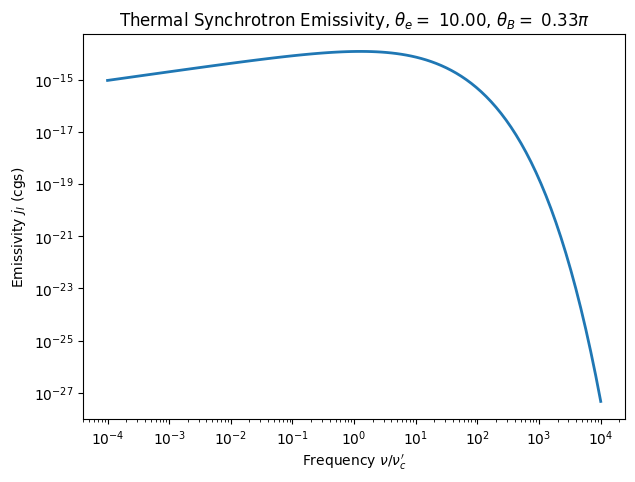

In [283]:
plt.figure(figsize=(7, 5))
plt.loglog(nuOvernuc, j_I, linewidth=2)
plt.xlabel(r"Frequency $\nu/\nu_c'$")
plt.ylabel(r'Emissivity $j_I$ (cgs)')
plt.title(fr'Thermal Synchrotron Emissivity, $\theta_e =$ {theta_e:.2f}, $\theta_B =$ {theta_B/np.pi:.2f}$\pi$')
plt.show()

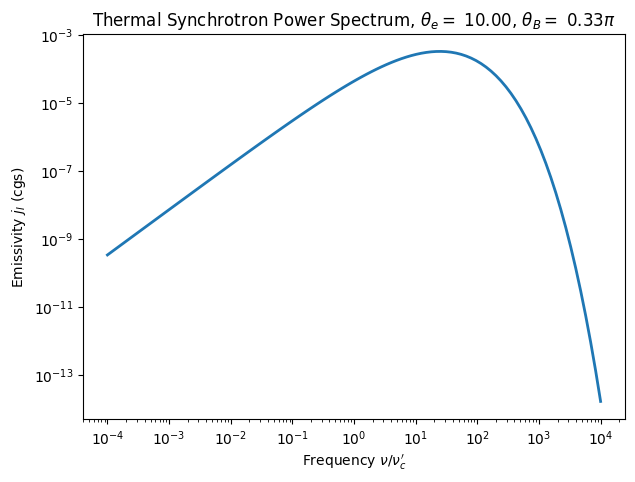

In [284]:
plt.figure(figsize=(7, 5))
plt.loglog(nuOvernuc, nu*j_I, linewidth=2)
plt.xlabel(r"Frequency $\nu/\nu_c'$")
plt.ylabel(r'Emissivity $j_I$ (cgs)')
plt.title(fr'Thermal Synchrotron Power Spectrum, $\theta_e =$ {theta_e:.2f}, $\theta_B =$ {theta_B/np.pi:.2f}$\pi$')
plt.show()

### Ranging over $\theta_B$

In [285]:
theta_Bs = np.arccos(np.linspace(0.01, 0.999, 5))  #np.pi*angle_Bs/180.
angle_Bs = 180./np.pi * theta_Bs # np.array([15., 30., 45., 60., 90.])
nus = np.array([nuOvernuc*nuc_prime(B, theta_e, thB) for thB in theta_Bs])

j_Is = np.array([jI(nus[i], n, B, theta_e, theta_Bs[i]) for i in range(len(theta_Bs))])

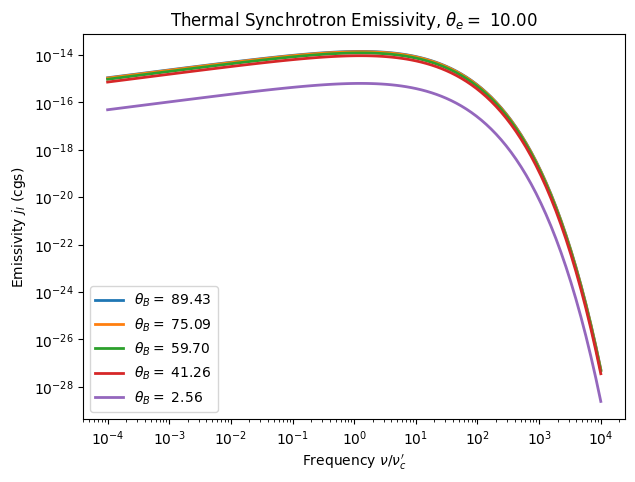

In [286]:
plt.figure(figsize=(7, 5))
[plt.loglog(nuOvernuc, j_Is[i], linewidth=2, label=fr"$\theta_B =$ {angle_Bs[i]:.2f}") for i in range(len(j_Is))]
plt.xlabel(r"Frequency $\nu/\nu_c'$")
plt.ylabel(r'Emissivity $j_I$ (cgs)')
plt.title(fr'Thermal Synchrotron Emissivity, $\theta_e =$ {theta_e:.2f}')
plt.legend()
plt.show()

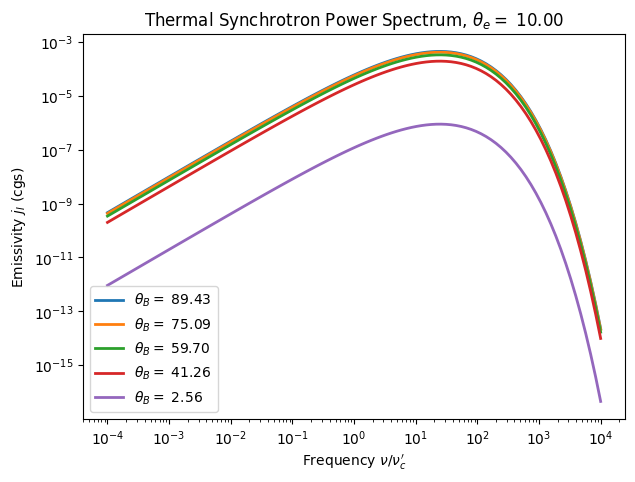

In [287]:
plt.figure(figsize=(7, 5))
[plt.loglog(nuOvernuc, nus[i]*j_Is[i], linewidth=2, label=fr"$\theta_B =$ {angle_Bs[i]:.2f}") for i in range(len(j_Is))]
plt.xlabel(r"Frequency $\nu/\nu_c'$")
plt.ylabel(r'Emissivity $j_I$ (cgs)')
plt.title(fr'Thermal Synchrotron Power Spectrum, $\theta_e =$ {theta_e:.2f}')
plt.legend()
plt.show()

### Finding maximums

In [390]:
# Equivalently, we find the minimum of the negative
# Precompute II(x) on a log grid once per theta_e, then reuse for any theta_B
_x_grid = np.logspace(np.log10(minnuRel), np.log10(maxnuRel), 2000)

def build_ii_cache(theta_e):
    _ii_grid = II_vec(_x_grid, theta_e)
    ii_spline = CubicSpline(np.log(_x_grid), np.log(_ii_grid))
    return ii_spline

def maxvals(theta_e, theta_B, printVals=False):
    nu_c = nuc_prime(B, theta_e, theta_B)
    ii_spline = build_ii_cache(theta_e)
    
    def jI_from_x(x):
        prefactor = n * q_e**2 * (x * nu_c) / (2.*np.sqrt(3.)*c*theta_e**2)
        # Use cached spline; clip to valid log range
        logx = np.clip(np.log(x), np.log(_x_grid[0]), np.log(_x_grid[-1]))
        return prefactor * np.exp(ii_spline(logx))
    
    neg_jI = lambda x: -jI_from_x(x)
    res_emiss = minimize_scalar(neg_jI, bounds=(minnuRel, maxnuRel), method='bounded')
    neg_PS = lambda x: -(x * nu_c) * jI_from_x(x)
    res_PS = minimize_scalar(neg_PS, bounds=(minnuRel, maxnuRel), method='bounded')

    if(printVals):
        print(f"--- Emissivity + Power Spectrum Peak ---")
        print(f"x = nu/nu_c' = {res_emiss.x:.6f}, {res_PS.x:.6f}")
        print(f"Peak Value (cgs): {-res_emiss.fun:.6e}, {-res_PS.fun:.6e}")
    return -res_emiss.fun, -res_PS.fun

In [391]:
theta_e = 10.
maxvals(theta_e, theta_B, True);

--- Emissivity + Power Spectrum Peak ---
x = nu/nu_c' = 1.271322, 24.621264
Peak Value (cgs): 2.759127e+06, 1.120381e+27


In [396]:
def returnPeaks(theta_e, theta_Bs, get_pos):
    ii_spline = build_ii_cache(theta_e)
    
    j_peaks = np.empty_like(theta_Bs)
    PS_peaks = np.empty_like(theta_Bs)
    j_xpeaks = np.empty_like(theta_Bs)
    PS_xpeaks = np.empty_like(theta_Bs)
    
    for i, thB in enumerate(theta_Bs):
        nu_c = nuc_prime(B, theta_e, thB)
        
        def jI_from_x(x):
            prefactor = n * q_e**2 * (x * nu_c) / (2.*np.sqrt(3.)*c*theta_e**2)
            logx = np.clip(np.log(x), np.log(_x_grid[0]), np.log(_x_grid[-1]))
            return prefactor * np.exp(ii_spline(logx))
        
        neg_jI = lambda x: -jI_from_x(x)
        res_emiss = minimize_scalar(neg_jI, bounds=(minnuRel, maxnuRel), method='bounded')
        neg_PS = lambda x: -(x * nu_c) * jI_from_x(x)
        res_PS = minimize_scalar(neg_PS, bounds=(minnuRel, maxnuRel), method='bounded')
        
        j_peaks[i] = -res_emiss.fun
        PS_peaks[i] = -res_PS.fun
        j_xpeaks[i] = res_emiss.x
        PS_xpeaks[i] = res_PS.x
    
    if(get_pos): return j_peaks, PS_peaks, j_xpeaks, PS_xpeaks, 
    return j_peaks, PS_peaks

def peak_plot(theta_Bs, peaks, i, theta_e, cos_plot=False, logx=True, logy=True, extraLabel=""):
    if(not isinstance(theta_e, (np.ndarray, list))): theta_e = (theta_e, ); extraLabel=(extraLabel,)
    elif(extraLabel==""): extraLabel=(extraLabel,)*len(theta_e)
    if(len(np.shape(peaks)) < 2): peaks = (peaks, )
    plt.figure(figsize=(7, 5))
    if(logx): plt.xscale('log')
    if(logy): plt.yscale('log')
    if(cos_plot):
        [plt.plot(np.cos(theta_Bs), peaks[i], lw=2, label=fr"$\theta_e =$ {theta_e[i]:.2f} "+extraLabel[i], marker="o") for i in range(len(peaks))]
        plt.xlabel(r"$\cos \theta_B$")
    else: 
        [plt.plot(theta_Bs, peaks[i], lw=2, label=fr"$\theta_e =$ {theta_e[i]:.2f} "+extraLabel[i], marker="o") for i in range(len(peaks))]
        plt.xlabel(r"$\theta_B$");
    lbl = ["Peak emissivity $j_I$", "Power Law Peak"] 
    plt.ylabel(fr'{lbl[i]} (cgs)')
    plt.legend()
    plt.show()

In [368]:
# theta_Bs = np.arccos(np.logspace(-2, np.log10(0.999), 20))
theta_Bs = np.logspace(-2, np.log10(0.999*np.pi/2), 20)
j_peaks, PS_peaks = returnPeaks(theta_e, theta_Bs)

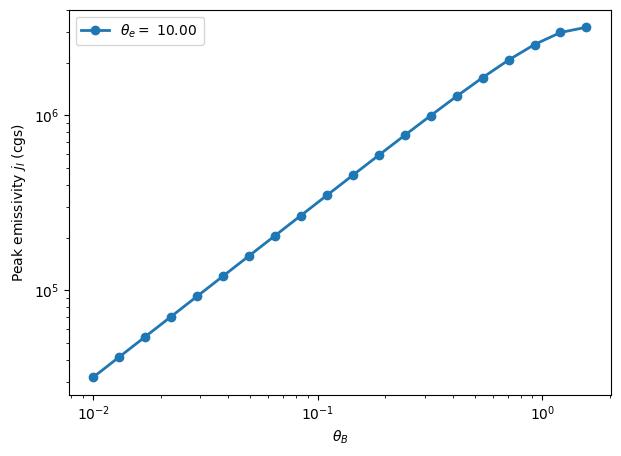

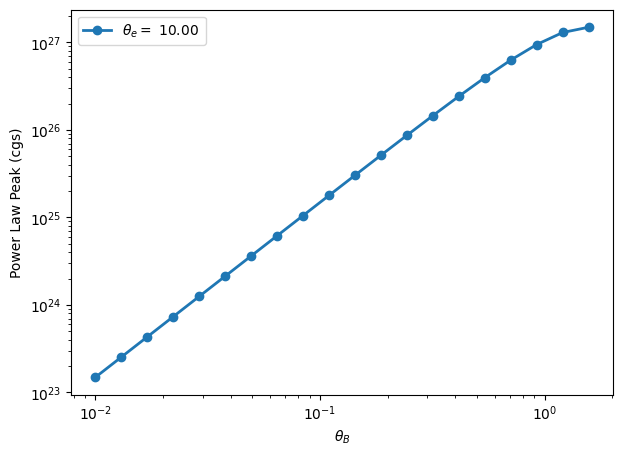

In [369]:
peak_plot(theta_Bs, j_peaks,  0, theta_e, cos_plot=False, logx=True, logy=True)
peak_plot(theta_Bs, PS_peaks, 1, theta_e, cos_plot=False, logx=True, logy=True)

#### Fitting along $\theta_B$

In [370]:
# np.polyfit(np.log10(theta_Bs), np.log10(j_peaks), deg=1, full=True)
logthB = np.log10(theta_Bs)
y_j, y_PS = np.log10(j_peaks), np.log10(PS_peaks)
[slope_j, b_j], [ss_res_j,], _, _, _ =   np.polyfit(logthB, y_j,  deg=1, full=True)
[slope_PS, b_PS], [ss_res_PS,], _, _, _ = np.polyfit(logthB, y_PS, deg=1, full=True)

j_peaks_fit = theta_Bs**slope_j * 10**b_j
PS_peaks_fit = theta_Bs**slope_PS * 10**b_PS

In [371]:
R2 = lambda ss_res, y: 1. - ss_res/np.sum((y - np.mean(y))**2)
print(fr"Slope, intercept, R^2 values")
print(fr"j:  {slope_j:.2f}, {b_j:.2f}, {R2(ss_res_j, y_j):.3f}")
print(fr"PS: {slope_PS:.2f}, {b_PS:.2f}, {R2(ss_res_PS, y_PS):.3f}")

Slope, intercept, R^2 values
j:  0.95, 6.44, 0.997
PS: 1.90, 27.04, 0.997


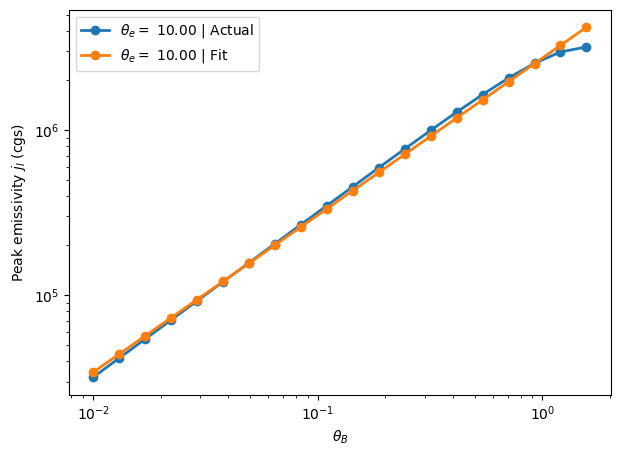

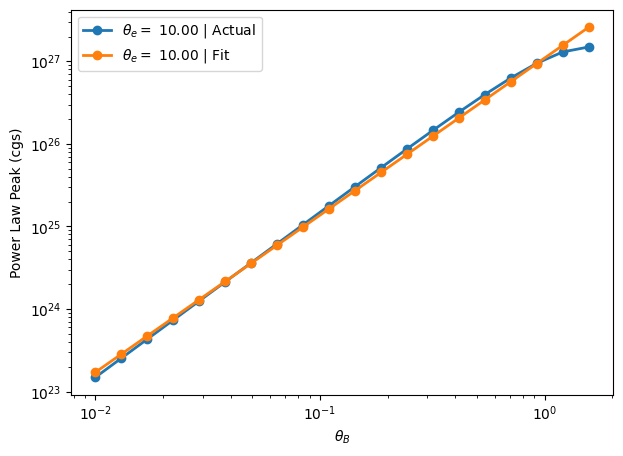

In [372]:
#Should I just ignore the last few points to the fit? 
peak_plot(theta_Bs, [j_peaks, j_peaks_fit],   0, [theta_e, theta_e], cos_plot=False, logx=True, logy=True, extraLabel=["| Actual", "| Fit"])
peak_plot(theta_Bs, [PS_peaks, PS_peaks_fit], 1, [theta_e, theta_e], cos_plot=False, logx=True, logy=True, extraLabel=["| Actual", "| Fit"])

### Ranging over $\theta_e$

In [377]:
theta_es = np.logspace(-2, 3, 10)
# theta_es = np.linspace(1e-2, 1e3, 10)
# theta_Bs = np.arccos(np.logspace(-2, np.log10(0.999), 20))
theta_Bs = np.logspace(-2, np.log10(0.999*np.pi/2), 20)
peakPeaks = np.transpose([(returnPeaks(theta_e, theta_Bs)) for theta_e in theta_es], (1, 0, 2))

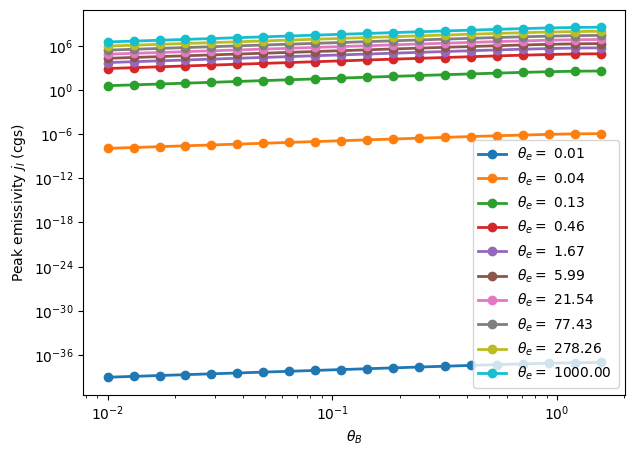

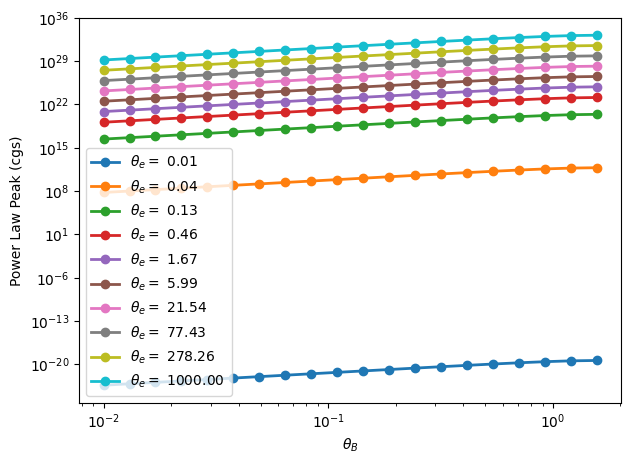

In [380]:
peak_plot(theta_Bs, peakPeaks[0], 0, theta_es, cos_plot=False, logx=True, logy=True)
peak_plot(theta_Bs, peakPeaks[1], 1, theta_es, cos_plot=False, logx=True, logy=True)

#### Flipped plots

In [ ]:
def normed(arr): return arr/max(arr)

In [443]:
#More points so we can get a better fit
theta_es = np.logspace(-2, 3, 20)
# theta_es = np.linspace(1e-2, 1e3, 20)
# theta_Bs = np.arccos(np.logspace(-2, np.log10(0.999), 20))
theta_Bs = np.logspace(-2, np.log10(0.999*np.pi/2), 20)
peakPeaksP = np.transpose([(returnPeaks(theta_e, theta_Bs,True)) for theta_e in theta_es], (1, 0, 2))
peakPeaksPFlipped = peakPeaksP.transpose((0, 2, 1))

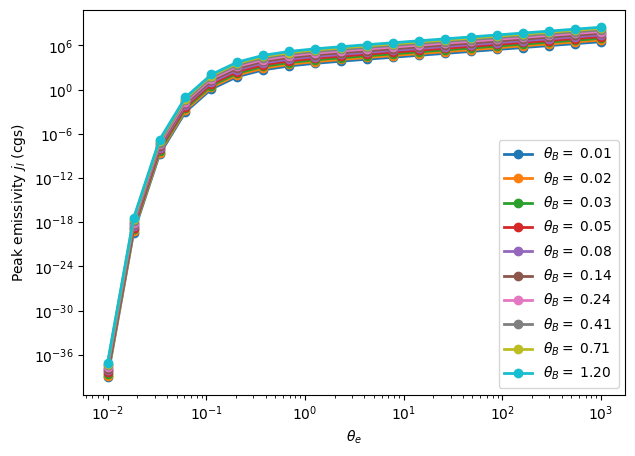

In [470]:
#Flipped plot
plt.figure(figsize=(7, 5))
[plt.plot(theta_es, peakPeaksPFlipped[0][i], lw=2, label=fr"$\theta_B =$ {theta_Bs[i]:.2f} ", marker="o") for i in range(0,len(theta_Bs),2)]
plt.yscale('log'); plt.xscale('log')
plt.xlabel(r"$\theta_e$"); plt.ylabel(fr'Peak emissivity $j_I$ (cgs)')
plt.legend(); plt.show()

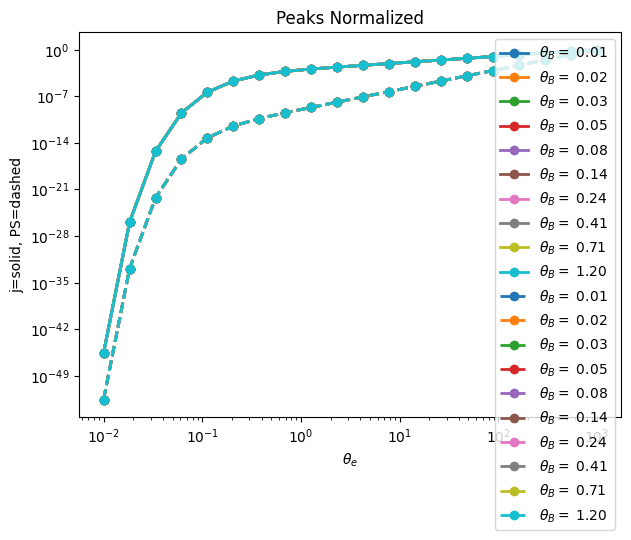

In [471]:
plt.figure(figsize=(7, 5))
[plt.plot(theta_es, normed(peakPeaksPFlipped[0][i]), lw=2, label=fr"$\theta_B =$ {theta_Bs[i]:.2f} ", marker="o") for i in range(0,len(theta_Bs),2)]
[plt.plot(theta_es, normed(peakPeaksPFlipped[1][i]), lw=2, label=fr"$\theta_B =$ {theta_Bs[i]:.2f} ", marker="o",ls="dashed") for i in range(0,len(theta_Bs),2)]
plt.xlabel(r"$\theta_e$"); plt.ylabel(fr'j=solid, PS=dashed')
plt.yscale('log'); plt.xscale('log')
plt.title("Peaks Normalized")
plt.legend(); plt.show()

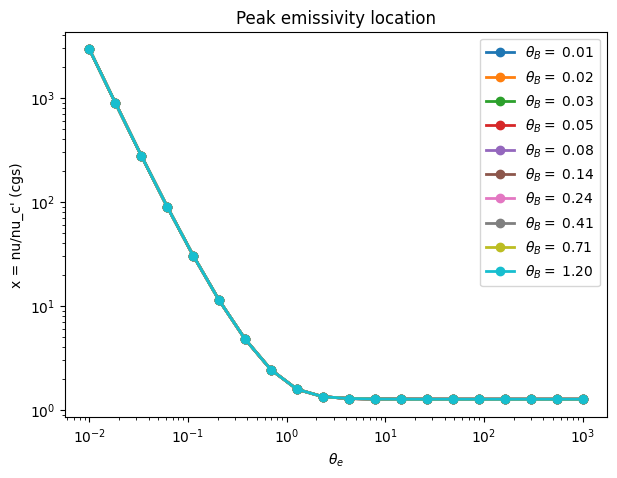

In [472]:
plt.figure(figsize=(7, 5))
[plt.plot(theta_es, peakPeaksPFlipped[2][i], lw=2, label=fr"$\theta_B =$ {theta_Bs[i]:.2f} ", marker="o") for i in range(0,len(theta_Bs),2)]
plt.yscale('log'); plt.xscale('log')
plt.xlabel(r"$\theta_e$"); plt.ylabel(fr"x = nu/nu_c' (cgs)")
plt.title("Peak emissivity location")
plt.legend(); plt.show()

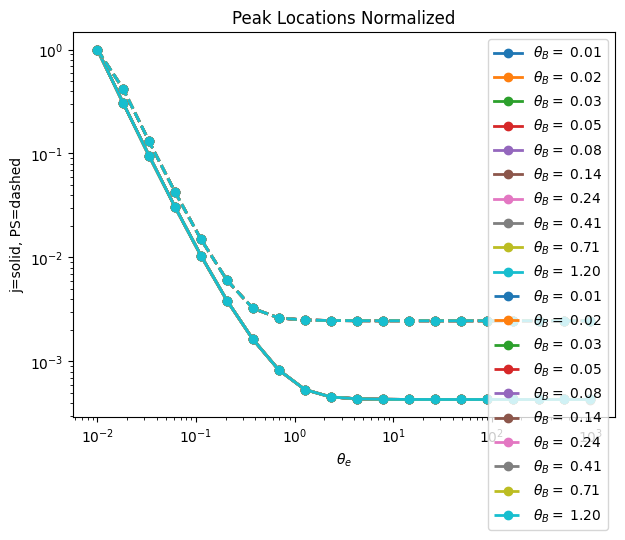

In [473]:
plt.figure(figsize=(7, 5))
[plt.plot(theta_es, normed(peakPeaksPFlipped[2][i]), lw=2, label=fr"$\theta_B =$ {theta_Bs[i]:.2f} ", marker="o") for i in range(0,len(theta_Bs),2)]
[plt.plot(theta_es, normed(peakPeaksPFlipped[3][i]), lw=2, label=fr"$\theta_B =$ {theta_Bs[i]:.2f} ", marker="o",ls="dashed") for i in range(0,len(theta_Bs),2)]
plt.yscale('log'); plt.xscale('log')
plt.xlabel(r"$\theta_e$"); plt.ylabel(fr'j=solid, PS=dashed')
plt.title("Peak Locations Normalized")
plt.legend(); plt.show()

#### Fitting along $\theta_e$

TODO: Need to figure out how to fit a log curve, cause I think this thing is a log curve (on an already-logged graph)


Then smash the functions together to approximate $j$

Also need to evaluate in the limit that $\theta_B \to \pi$ and 0

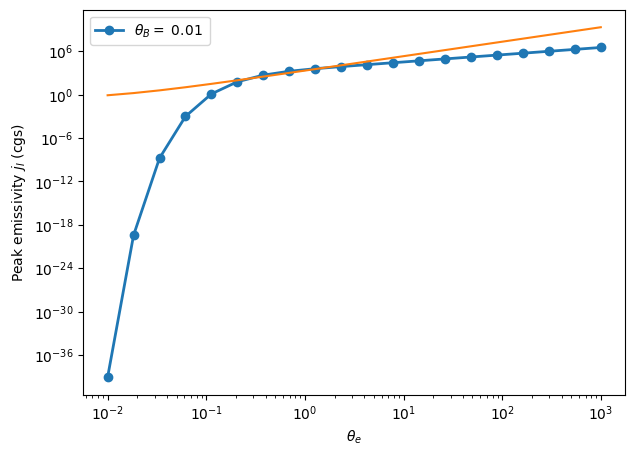

In [501]:
#Flipped plot
plt.figure(figsize=(7, 5))
plt.plot(theta_es, peakPeaksPFlipped[0][0], lw=2, label=fr"$\theta_B =$ {theta_Bs[0]:.2f} ", marker="o")
plt.plot(theta_es, 20*theta_e**(-2) * (1 + theta_es/theta_Bs[0])**(2))
plt.yscale('log'); plt.xscale('log')
plt.xlabel(r"$\theta_e$"); plt.ylabel(fr'Peak emissivity $j_I$ (cgs)')
plt.legend(); plt.show()

In [ ]:
# np.polyfit(np.log10(theta_Bs), np.log10(j_peaks), deg=1, full=True)
logthe = np.log10(theta_es)
y_j, y_PS = np.log10(np.log10(peakPeaksPFlipped[0][0])), np.log10(np.log10(peakPeaksPFlipped[1][0]))
[slope_j, b_j], [ss_res_j,], _, _, _ =   np.polyfit(logthB, y_j,  deg=1, full=True)
[slope_PS, b_PS], [ss_res_PS,], _, _, _ = np.polyfit(logthB, y_PS, deg=1, full=True)

j_peaks_fit = theta_Bs**slope_j * 10**b_j
PS_peaks_fit = theta_Bs**slope_PS * 10**b_PS

In [ ]:
R2 = lambda ss_res, y: 1. - ss_res/np.sum((y - np.mean(y))**2)
print(fr"Slope, intercept, R^2 values")
print(fr"j:  {slope_j:.2f}, {b_j:.2f}, {R2(ss_res_j, y_j):.3f}")
print(fr"PS: {slope_PS:.2f}, {b_PS:.2f}, {R2(ss_res_PS, y_PS):.3f}")

Slope, intercept, R^2 values
j:  0.95, 6.44, 0.997
PS: 1.90, 27.04, 0.997


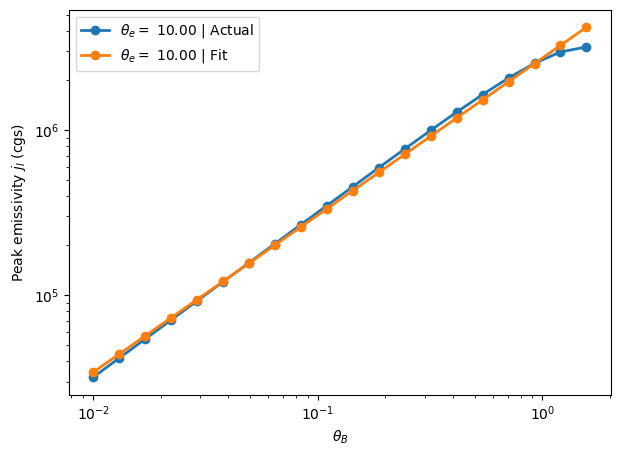

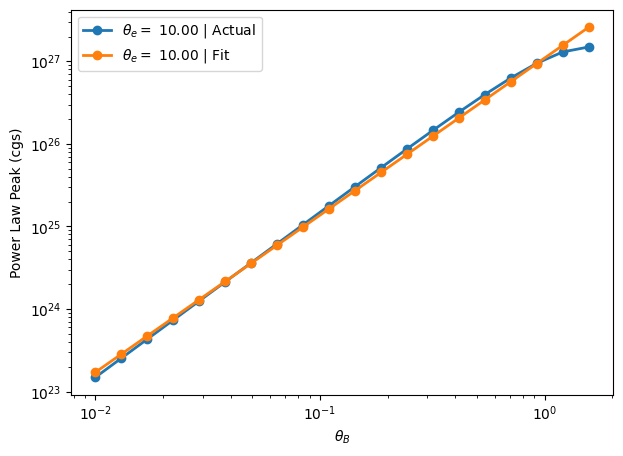

In [ ]:
#Should I just ignore the last few points to the fit? 
peak_plot(theta_Bs, [j_peaks, j_peaks_fit],   0, [theta_e, theta_e], cos_plot=False, logx=True, logy=True, extraLabel=["| Actual", "| Fit"])
peak_plot(theta_Bs, [PS_peaks, PS_peaks_fit], 1, [theta_e, theta_e], cos_plot=False, logx=True, logy=True, extraLabel=["| Actual", "| Fit"])